In [1]:
import json

In [2]:
def get_max_score_by_kth_refusal(data, k):
    """
    Get the maximum numeric score before the (k+1)th refusal.
    
    Args:
        data: a JSON string containing the attack entries
        k: Number of refusals to check before
        
    Returns:
        Maximum numeric score found before (k+1)th refusal, or 0.0 if no scores exist
    """
    # Parse data if it's a string
    if isinstance(data, str):
        entries = []
        for line in data.strip().split('\n'):
            if line.strip():
                try:
                    entries.append(json.loads(line))
                except json.JSONDecodeError:
                    continue

    refusal_count = 0
    max_score = 0.0
    
    for entry in entries:
        # Skip the first entry if it's metadata (contains target_base_url, etc.)
        if 'target_base_url' in entry:
            continue
            
        score = entry.get('score')
        
        # Check if this is a refusal
        if score == "refused":
            refusal_count += 1
            # If we've reached the (k+1)th refusal, stop checking
            if refusal_count >= k + 1:
                break
        # Check if we have a numeric score and update max
        elif isinstance(score, (int, float)) and score > max_score:
            max_score = score
    
    return max_score

def count_total_refusals(data):
    """
    Count the total number of entries with score "refused".
    
    Args:
        data: a JSON string containing the attack entries
        
    Returns:
        Total number of refusals
    """
    # Parse data if it's a string
    if isinstance(data, str):
        entries = []
        for line in data.strip().split('\n'):
            if line.strip():
                try:
                    entries.append(json.loads(line))
                except json.JSONDecodeError:
                    continue
    
    refusal_count = 0
    
    for entry in entries:
        # Skip the first entry if it's metadata (contains target_base_url, etc.)
        if 'target_base_url' in entry:
            continue
            
        score = entry.get('score')
        if score == "refused":
            refusal_count += 1
    
    return refusal_count

def read_json_file(file_path):
    """
    Read a JSON file and return its content.
    
    Args:
        file_path: Path to the JSON file
    Returns:
        a json string containing the file content
    """
    with open(file_path, 'r') as file:
        return file.read()


In [3]:
import json
import pandas as pd
import os
from pathlib import Path
from typing import Dict, List, Optional

def load_jsonl_metadata(file_path: str) -> Optional[Dict]:
    """
    Load a JSONL file and extract metadata from the first line.
    
    Args:
        file_path (str): Path to the JSONL file
        
    Returns:
        Dict: Dictionary containing the metadata fields, or None if error
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            # Read the first line which contains metadata
            first_line = file.readline().strip()
            if first_line:
                metadata = json.loads(first_line)
                # Extract only the required fields
                return {
                    'jailbreak_tactic': metadata.get('jailbreak_tactic'),
                    'test_case': metadata.get('test_case'),
                    'target_model': metadata.get('target_model'),
                    'turn_type': metadata.get('turn_type'),
                    'timestamp': metadata.get('timestamp')
                }
    except (json.JSONDecodeError, FileNotFoundError, Exception) as e:
        print(f"Error processing file {file_path}: {e}")
        return None

def extract_all_metadata(root_directory: str) -> pd.DataFrame:
    """
    Extract metadata from all JSONL files in a directory and its subfolders,
    but only include files with jailbreak_tactic='direct_request'.
    
    Args:
        root_directory (str): Root directory path to search for JSONL files
        
    Returns:
        pd.DataFrame: DataFrame with columns ['jailbreak_tactic', 'test_case', 'target_model', 'turn_type', 'timestamp', 'file_path']
    """
    metadata_list = []
    
    # Use pathlib to recursively find all .jsonl files
    root_path = Path(root_directory)
    jsonl_files = list(root_path.rglob('*.jsonl'))
    
    print(f"Found {len(jsonl_files)} JSONL files to process...")
    
    direct_request_count = 0
    for file_path in jsonl_files:
        metadata = load_jsonl_metadata(str(file_path))
        if metadata:
            # Only process files with direct_request tactic
            if metadata.get('jailbreak_tactic') == 'direct_request':
                # Add the file path for reference
                metadata['file_path'] = str(file_path)
                
                data = read_json_file(str(file_path))
                total_refusals = count_total_refusals(data)
                metadata['total_refusals'] = total_refusals
                for k in range(0, 11):
                    max_score = get_max_score_by_kth_refusal(data, k)
                    metadata[f'max_score_by_{k}_refusal'] = max_score
                metadata_list.append(metadata)
                direct_request_count += 1
        else:
            print(f"Skipped file due to error: {file_path}")
    
    # Create DataFrame
    df = pd.DataFrame(metadata_list)
    
    print(f"Successfully processed {direct_request_count} direct_request files out of {len(jsonl_files)} total files")
    return df

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List

def get_max_score_columns(df: pd.DataFrame) -> List[str]:
    """
    Get the max score columns from the DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame containing the max score data
        
    Returns:
        List[str]: List of max score column names sorted by k value
    """
    max_score_columns = [col for col in df.columns if col.startswith('max_score_by_') and col.endswith('_refusal')]
    
    # Extract k values from column names
    k_values = []
    for col in max_score_columns:
        k = col.replace('max_score_by_', '').replace('_refusal', '')
        k_values.append(int(k))
    
    # Sort to ensure proper order
    k_values.sort()
    max_score_columns = [f'max_score_by_{k}_refusal' for k in k_values]
    
    return max_score_columns, k_values

def analyze_max_scores_by_model(df: pd.DataFrame) -> Dict:
    """
    Calculate average maximum scores by refusal count for each target model.
    Note: Since we're only using direct_request data, no need for by_tactic parameter.
    
    Args:
        df (pd.DataFrame): DataFrame containing the max score data
        
    Returns:
        Dict: Dictionary with target_model as keys and DataFrames with k and avg_max_score as values
    """
    # Get the max score columns (max_score_by_k_refusal)
    max_score_columns, k_values = get_max_score_columns(df)

    results = {}
    
    # Group by target_model only
    for model in df['target_model'].unique():
        model_data = df[df['target_model'] == model]
        
        avg_max_scores = []
        for col in max_score_columns:
            avg_score = model_data[col].mean()
            avg_max_scores.append(avg_score)
        
        # Create DataFrame for this model
        model_results = pd.DataFrame({
            'k': k_values,
            'avg_max_score': avg_max_scores
        })
        
        results[model] = model_results
    
    return results

def get_summary_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Get summary statistics for max scores by model.
    
    Args:
        df (pd.DataFrame): DataFrame containing the max score data
        
    Returns:
        pd.DataFrame: Summary statistics table
    """
    results = analyze_max_scores_by_model(df)
    
    summary_data = []
    for key, model_data in results.items():
        row_data = {
            'target_model': key,
            'min_avg_max_score': model_data['avg_max_score'].min(),
            'max_avg_max_score': model_data['avg_max_score'].max(),
            'mean_avg_max_score': model_data['avg_max_score'].mean(),
            'final_avg_max_score': model_data['avg_max_score'].iloc[-1],
            'total_experiments': len(df[df['target_model'] == key])
        }
        
        summary_data.append(row_data)
    
    return pd.DataFrame(summary_data)

In [5]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [6]:
def formula(k, A, B, c):
    return A - B * np.exp(-c * k)

In [7]:
def fit_formula(k_data, y_data):
    """
    Fit the model to the data using curve fitting.
    
    Args:
        k_data: Array of k values (number of refusals)
        y_data: Array of average max scores corresponding to k values
        
    Returns:
        Fitted parameters A, B, c
    """
    # Initial guess for parameters A, B, c
    initial_guess = [5.0, 3.0, 1.0]
    
    # Fit the model to the data
    params, covariance = curve_fit(formula, k_data, y_data, p0=initial_guess)
    
    return params

In [8]:
def plot_curve_fit(k_data, y_data):
    """
    Plot the original data and the fitted curve.
    
    Args:
        k_data: Array of k values (number of refusals)
        y_data: Array of average max scores corresponding to k values
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(k_data, y_data, label='Data', color='blue')
    
    # Generate fitted curve
    # k_fit = np.linspace(min(k_data), max(k_data), 100)
    params = fit_formula(k_data, y_data)
    y_fit = formula(k_data, *params)

    # calculate RMSE between original data and fitted curve
    rmse = np.sqrt(np.mean((y_data - y_fit)**2))
    print(f"RMSE: {rmse:.4f}")
    
    plt.plot(k_data, y_fit, label='Fitted Curve', color='red')
    
    plt.xlabel('Number of Refusals (k)')
    plt.ylabel('Average Maximum Score')
    plt.title('Curve Fit to Average Maximum Score Data')
    plt.legend()
    plt.grid(True)
    plt.show()

    A, B, c = params
    # recover model parameters
    p = 1 - np.exp(-c)
    p_0 = 1 - (B/A)* np.exp(-c)
    print(f"Fitted parameters:\nA: {A:.4f}, B: {B:.4f}, c: {c:.4f}\np: {p:.4f}, p_0: {p_0:.4f}")

In [9]:
def plot_max_scores_by_model(df: pd.DataFrame, by_turn_type: bool = False, figsize=(15, 10), save_path=None):
    """
    Plot average maximum scores by refusal count for each target model.
    If by_turn_type=True, shows one plot per model with both turn types as different lines.

    Args:
        df (pd.DataFrame): DataFrame containing the max score data
        by_turn_type (bool): If True, plot both turn types on the same graph per model
        figsize (tuple): Figure size for the plot
        save_path (str, optional): Path to save the plot
    """
    if by_turn_type:
        results_multi_turn = analyze_max_scores_by_model(df[df["turn_type"]=="multi"])
        results_single_turn = analyze_max_scores_by_model(df[df["turn_type"]=="single"])
        assert results_multi_turn.keys() == results_single_turn.keys(), \
            "Multi-turn and single-turn results don't have the same models."
        # Use multi_turn results to determine the models to plot
        results = results_multi_turn
    else:
        results = analyze_max_scores_by_model(df)

    # Calculate subplot layout
    n_plots = len(results)
    n_cols = min(3, n_plots)  # Max 3 columns
    n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Handle case where there's only one subplot
    if n_plots == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if n_plots > 1 else [axes]
    else:
        axes = axes.flatten()

    # Plot each model
    for i, (model, model_data) in enumerate(results.items()):
        ax = axes[i]
        
        if by_turn_type:
            # Plot both turn types as different lines
            # Multi-turn data
            k_multi = model_data['k']
            y_multi = model_data['avg_max_score']

            # Scatter plot for real data
            ax.scatter(k_multi, y_multi, color='blue', s=50, alpha=0.7, label='Multi-turn (data)')
            
            # Fit and plot curve for multi-turn
            try:
                params_multi = fit_formula(k_multi, y_multi)
                y_fit_multi = formula(k_multi, *params_multi)

                rmse_multi = np.sqrt(np.mean((y_multi - y_fit_multi)**2))
                A, B, c = params_multi
                p = 1 - np.exp(-c)
                p_0 = 1 - (B/A)* np.exp(-c)
                print(f"Multi-turn {model} - A: {A:.4f}, B: {B:.4f}, c: {c:.4f}, p: {p:.4f}, p_0: {p_0:.4f}, RMSE: {rmse_multi:.4f}")

                ax.plot(k_multi, y_fit_multi, color='blue', linewidth=2, label=f'Multi-turn (fitted, c={c:.4f})')

            except Exception as e:
                print(f"Could not fit curve for {model} multi-turn: {e}")
            
            # Single-turn line (if model exists in single-turn results)
            if model in results_single_turn:
                single_data = results_single_turn[model]
                k_single = np.array(single_data['k'])
                y_single = np.array(single_data['avg_max_score'])

                # Scatter plot for single-turn data
                ax.scatter(k_single, y_single, color='red', s=50, alpha=0.7, label='Single-turn (data)')
                try:
                    params_single = fit_formula(k_single, y_single)
                    y_fit_single = formula(k_single, *params_single)

                    rmse_single = np.sqrt(np.mean((y_single - y_fit_single)**2))
                    A, B, c = params_single
                    p = 1 - np.exp(-c)
                    p_0 = 1 - (B/A)* np.exp(-c)
                    print(f"Single-turn {model} - A: {A:.4f}, B: {B:.4f}, c: {c:.4f}, p: {p:.4f}, p_0: {p_0:.4f}, RMSE: {rmse_single:.4f}")

                    ax.plot(k_single, y_fit_single, color='red', linewidth=2, label=f'Single-turn (fitted, c={c:.4f})')

                except Exception as e:
                    print(f"Could not fit curve for {model} single-turn: {e}")
            
            # Add legend
            ax.legend()
            
        else:
            # Plot all data together (since it's all direct_request)
            k_values = model_data['k']
            y_values = model_data['avg_max_score']

            # Scatter plot for real data
            ax.scatter(k_values, y_values, color='blue', s=50, alpha=0.7, label='Data')
            
            # Fit and plot curve
            try:
                params = fit_formula(k_values, y_values)
                y_fit = formula(k_values, *params)

                rmse = np.sqrt(np.mean((y_values - y_fit)**2))
                A, B, c = params
                p = 1 - np.exp(-c)
                p_0 = 1 - (B/A)* np.exp(-c)
                print(f"{model} - A: {A:.4f}, B: {B:.4f}, c: {c:.4f}, p: {p:.4f}, p_0: {p_0:.4f}, RMSE: {rmse:.4f}")

                ax.plot(k_values, y_fit, color='red', linewidth=2, label=f'Fitted (c={c:.4f})')

            except Exception as e:
                print(f"Could not fit curve for {model}: {e}")
                
            # Add legend
            ax.legend()
        
        # Customize the plot
        ax.set_title(model, fontsize=12, fontweight='bold')
        ax.set_xlabel('Number of Refusals', fontsize=10)
        ax.set_ylabel('Average Maximum Score', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)  # Scores should be between 0 and 1
        
        # Set x-axis ticks to show all k values
        ax.set_xticks(model_data['k'])
    
    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()

def plot_refusal_frequency_histograms(df: pd.DataFrame, by_turn_type: bool = False, figsize=(15, 10), save_path=None):
    """
    Plot histograms of refusal frequency (k values) for each target model.
    If by_turn_type=True, shows separate histograms for multi-turn and single-turn.

    Args:
        df (pd.DataFrame): DataFrame containing the refusal data
        by_turn_type (bool): If True, separate histograms for each turn type
        figsize (tuple): Figure size for the plot
        save_path (str, optional): Path to save the plot
    """
    models = df['target_model'].unique()
    
    # Calculate subplot layout
    n_plots = len(models)
    n_cols = min(3, n_plots)  # Max 3 columns
    n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Handle case where there's only one subplot
    if n_plots == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if n_plots > 1 else [axes]
    else:
        axes = axes.flatten()

    # Plot each model
    for i, model in enumerate(models):
        ax = axes[i]
        model_data = df[df['target_model'] == model]
        
        if by_turn_type:
            # Plot separate histograms for multi-turn and single-turn
            multi_data = model_data[model_data['turn_type'] == 'multi']
            single_data = model_data[model_data['turn_type'] == 'single']
            
            # Create bins for k values (0 to max refusals)
            max_refusals = max(model_data['total_refusals'].max(), 10)
            bins = np.arange(0, max_refusals + 2) - 0.5  # Center bins on integers
            
            if len(multi_data) > 0:
                ax.hist(multi_data['total_refusals'], bins=bins, alpha=0.6, 
                       label=f'Multi-turn (n={len(multi_data)})', color='blue', edgecolor='black')
            
            if len(single_data) > 0:
                ax.hist(single_data['total_refusals'], bins=bins, alpha=0.6, 
                       label=f'Single-turn (n={len(single_data)})', color='red', edgecolor='black')
            
            ax.legend()
        else:
            # Plot combined histogram
            max_refusals = max(model_data['total_refusals'].max(), 10)
            bins = np.arange(0, max_refusals + 2) - 0.5  # Center bins on integers
            
            ax.hist(model_data['total_refusals'], bins=bins, alpha=0.7, 
                   color='blue', edgecolor='black')
        
        # Customize the plot
        ax.set_title(f'{model}\\n(n={len(model_data)}, μ={model_data["total_refusals"].mean():.2f})', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Number of Refusals (k)', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Set x-axis to show integer values
        ax.set_xticks(range(0, int(model_data['total_refusals'].max()) + 1))
    
    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()

In [10]:
metadata = extract_all_metadata('clean_results/final_runs/batch_1')

Found 6930 JSONL files to process...
Successfully processed 1260 direct_request files out of 6930 total files


Multi-turn gpt-4o-mini-2024-07-18 - A: 0.9533, B: 0.4817, c: 1.3607, p: 0.7435, p_0: 0.8704, RMSE: 0.0043
Single-turn gpt-4o-mini-2024-07-18 - A: 0.7459, B: 0.3957, c: 0.9854, p: 0.6267, p_0: 0.8020, RMSE: 0.0025
Multi-turn meta-llama/llama-3.1-70b-instruct - A: 0.9623, B: 0.2068, c: 2.6970, p: 0.9326, p_0: 0.9855, RMSE: 0.0005
Single-turn meta-llama/llama-3.1-70b-instruct - A: 0.8570, B: 0.1931, c: 2.8551, p: 0.9425, p_0: 0.9870, RMSE: 0.0002
Multi-turn meta-llama/llama-3.2-1b-instruct - A: 0.8955, B: 0.5729, c: 0.9201, p: 0.6015, p_0: 0.7451, RMSE: 0.0136
Single-turn meta-llama/llama-3.2-1b-instruct - A: 0.6194, B: 0.4706, c: 0.7823, p: 0.5427, p_0: 0.6525, RMSE: 0.0208
Multi-turn meta-llama/llama-3.2-3b-instruct - A: 0.9494, B: 0.3096, c: 1.2179, p: 0.7042, p_0: 0.9035, RMSE: 0.0094
Single-turn meta-llama/llama-3.2-3b-instruct - A: 0.7111, B: 0.3428, c: 0.9269, p: 0.6042, p_0: 0.8092, RMSE: 0.0080
Multi-turn meta-llama/llama-3.1-8b-instruct - A: 0.9384, B: 0.6483, c: 1.0465, p: 0.64

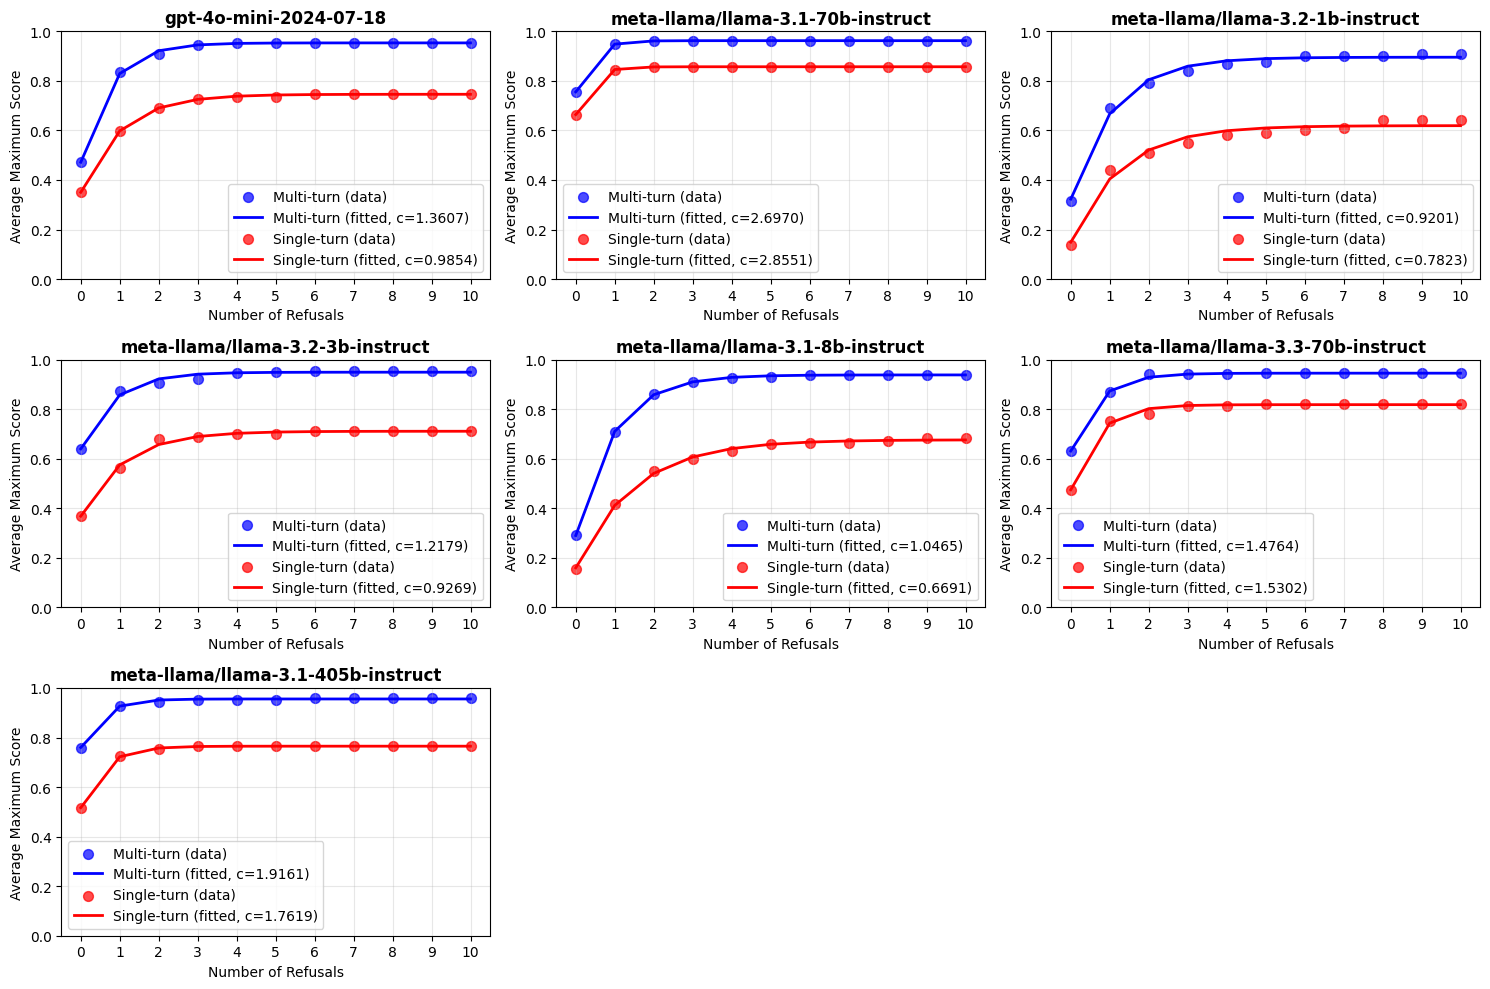


Refusal frequency histograms:


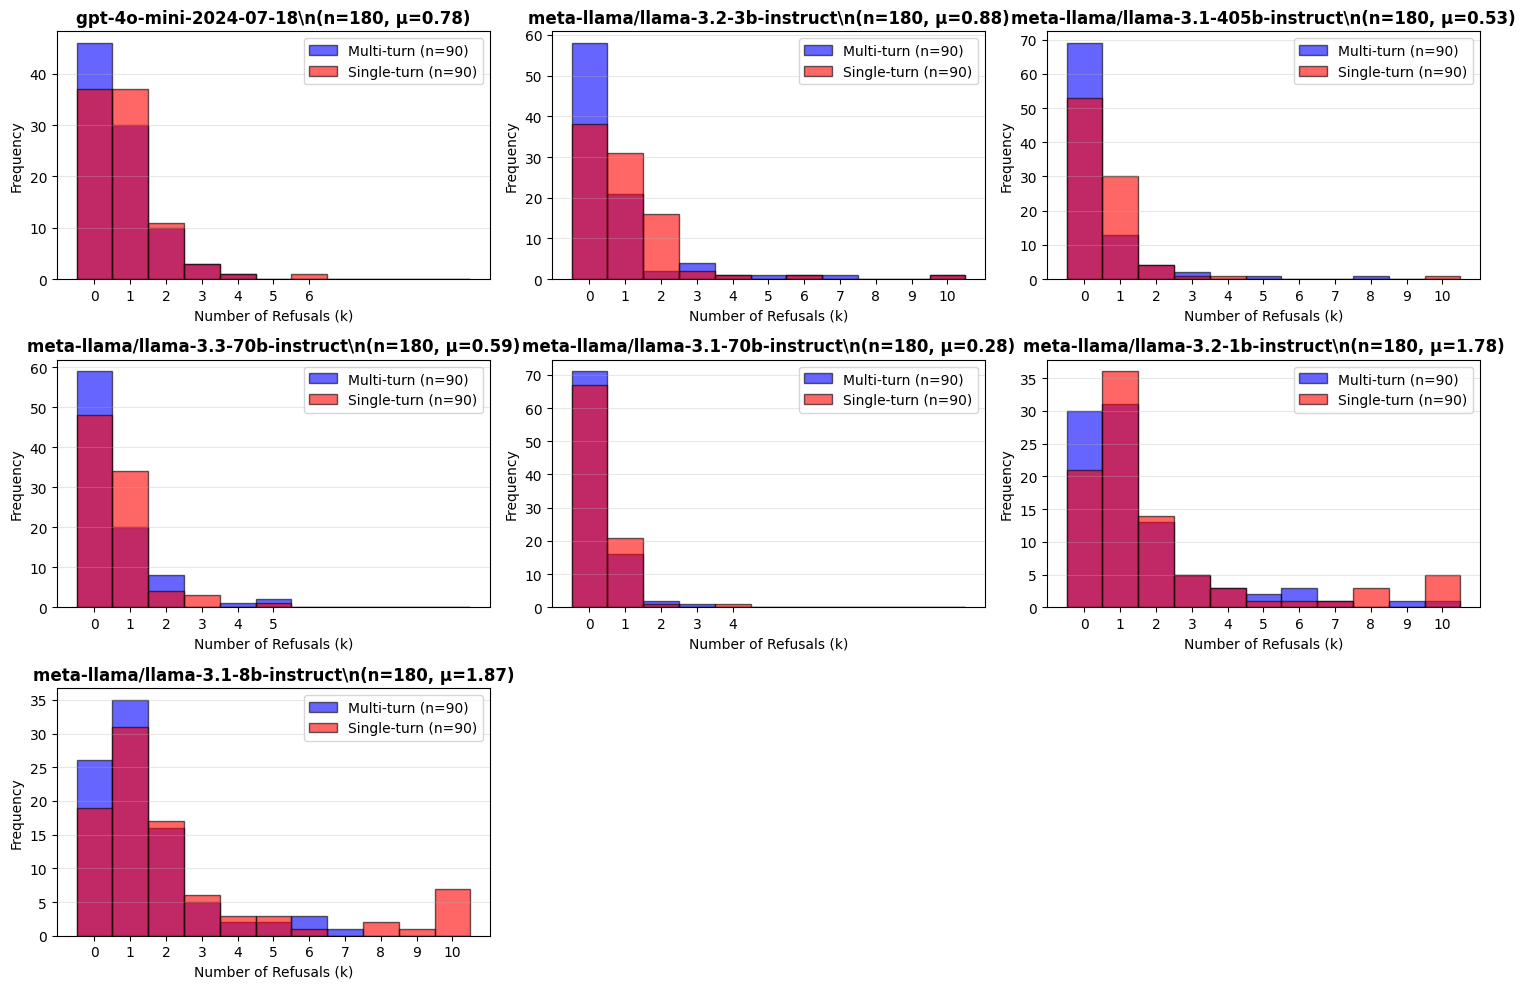

In [12]:
plot_max_scores_by_model(metadata, by_turn_type=True)

# Plot refusal frequency histograms
print("\nRefusal frequency histograms:")
plot_refusal_frequency_histograms(metadata, by_turn_type=True)

In [13]:
metadata3A = extract_all_metadata('clean_results/final_runs/batch3A')

Found 720 JSONL files to process...
Successfully processed 180 direct_request files out of 720 total files


In [14]:
metadata3A["turn_type"].value_counts()

turn_type
single    90
multi     90
Name: count, dtype: int64

Multi-turn openai/gpt-4.1-mini - A: 0.9131, B: 0.6129, c: 1.4778, p: 0.7719, p_0: 0.8468, RMSE: 0.0028
Single-turn openai/gpt-4.1-mini - A: 0.5751, B: 0.5012, c: 0.7479, p: 0.5266, p_0: 0.5875, RMSE: 0.0412
Multi-turn openai/gpt-4.1-nano - A: 0.8375, B: 0.3375, c: 21.7012, p: 1.0000, p_0: 1.0000, RMSE: 0.0000
Single-turn openai/gpt-4.1-nano - A: 0.5384, B: 0.2512, c: 1.6601, p: 0.8099, p_0: 0.9113, RMSE: 0.0027
Multi-turn openai/gpt-4.1 - A: 0.7048, B: 0.2507, c: 0.8803, p: 0.5853, p_0: 0.8525, RMSE: 0.0173
Single-turn openai/gpt-4.1 - A: 0.5022, B: 0.4033, c: 1.4673, p: 0.7695, p_0: 0.8149, RMSE: 0.0067
Multi-turn deepseek/deepseek-chat-v3-0324 - A: 0.5130, B: 0.2881, c: 2.0549, p: 0.8719, p_0: 0.9281, RMSE: 0.0014
Single-turn deepseek/deepseek-chat-v3-0324 - A: 0.3375, B: 0.3375, c: 21.7010, p: 1.0000, p_0: 1.0000, RMSE: 0.0000
Multi-turn anthropic/claude-3.5-sonnet - A: 0.4048, B: 0.4663, c: 0.2141, p: 0.1927, p_0: 0.0700, RMSE: 0.0612
Single-turn anthropic/claude-3.5-sonnet - A: 0.

/tmp/ipykernel_3812587/587640606.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(formula, k_data, y_data, p0=initial_guess)


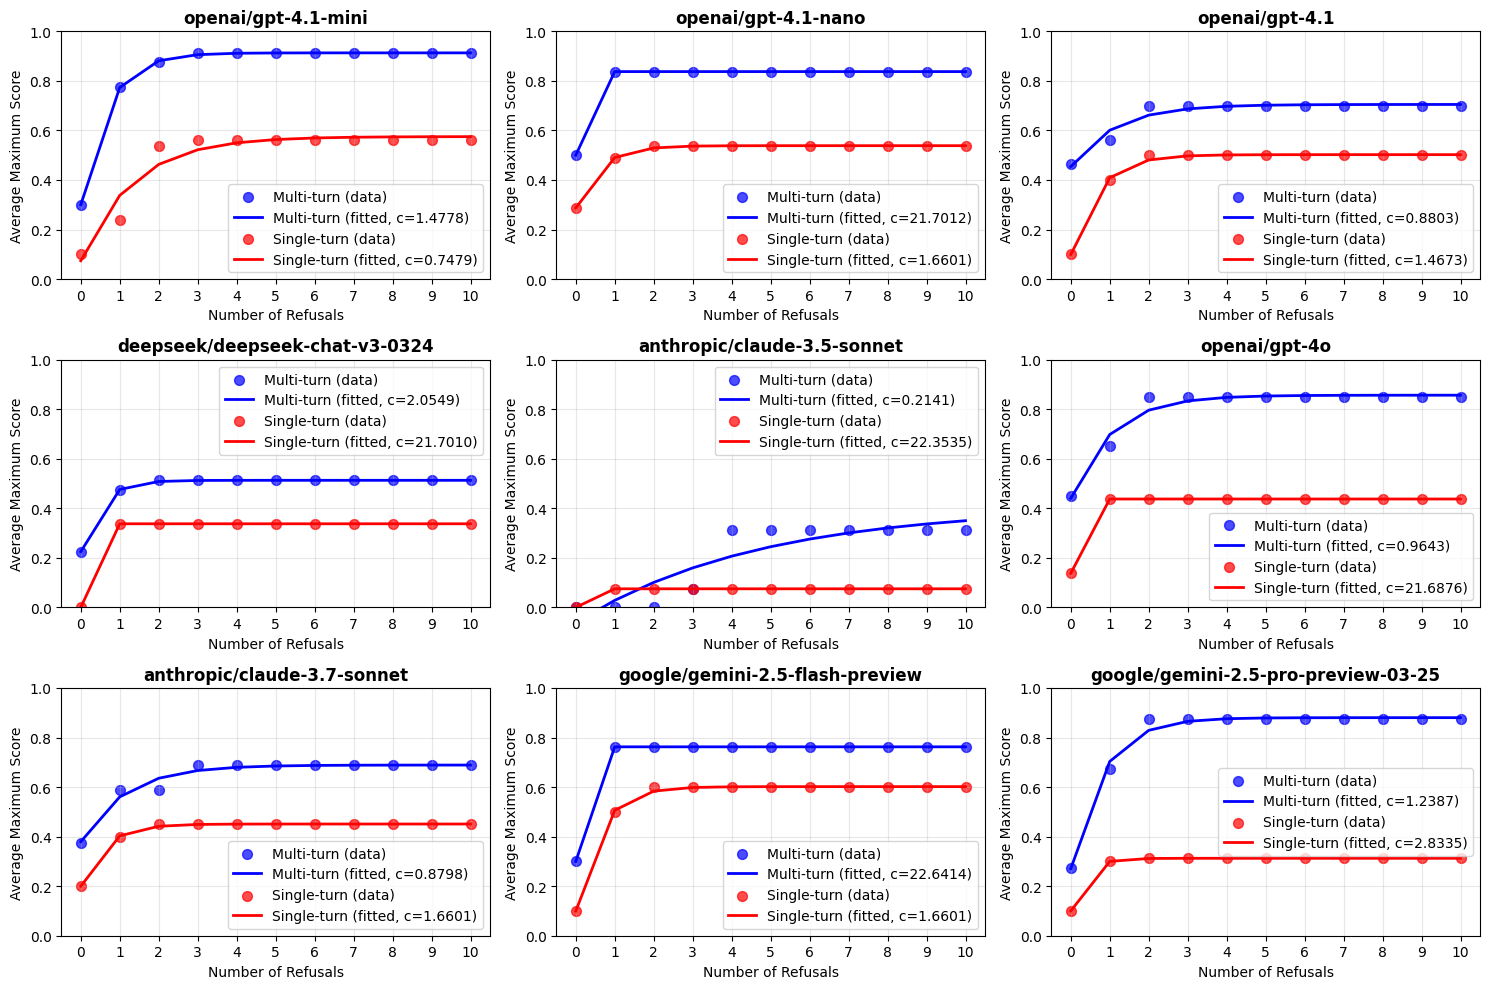


Batch3A refusal frequency histograms:


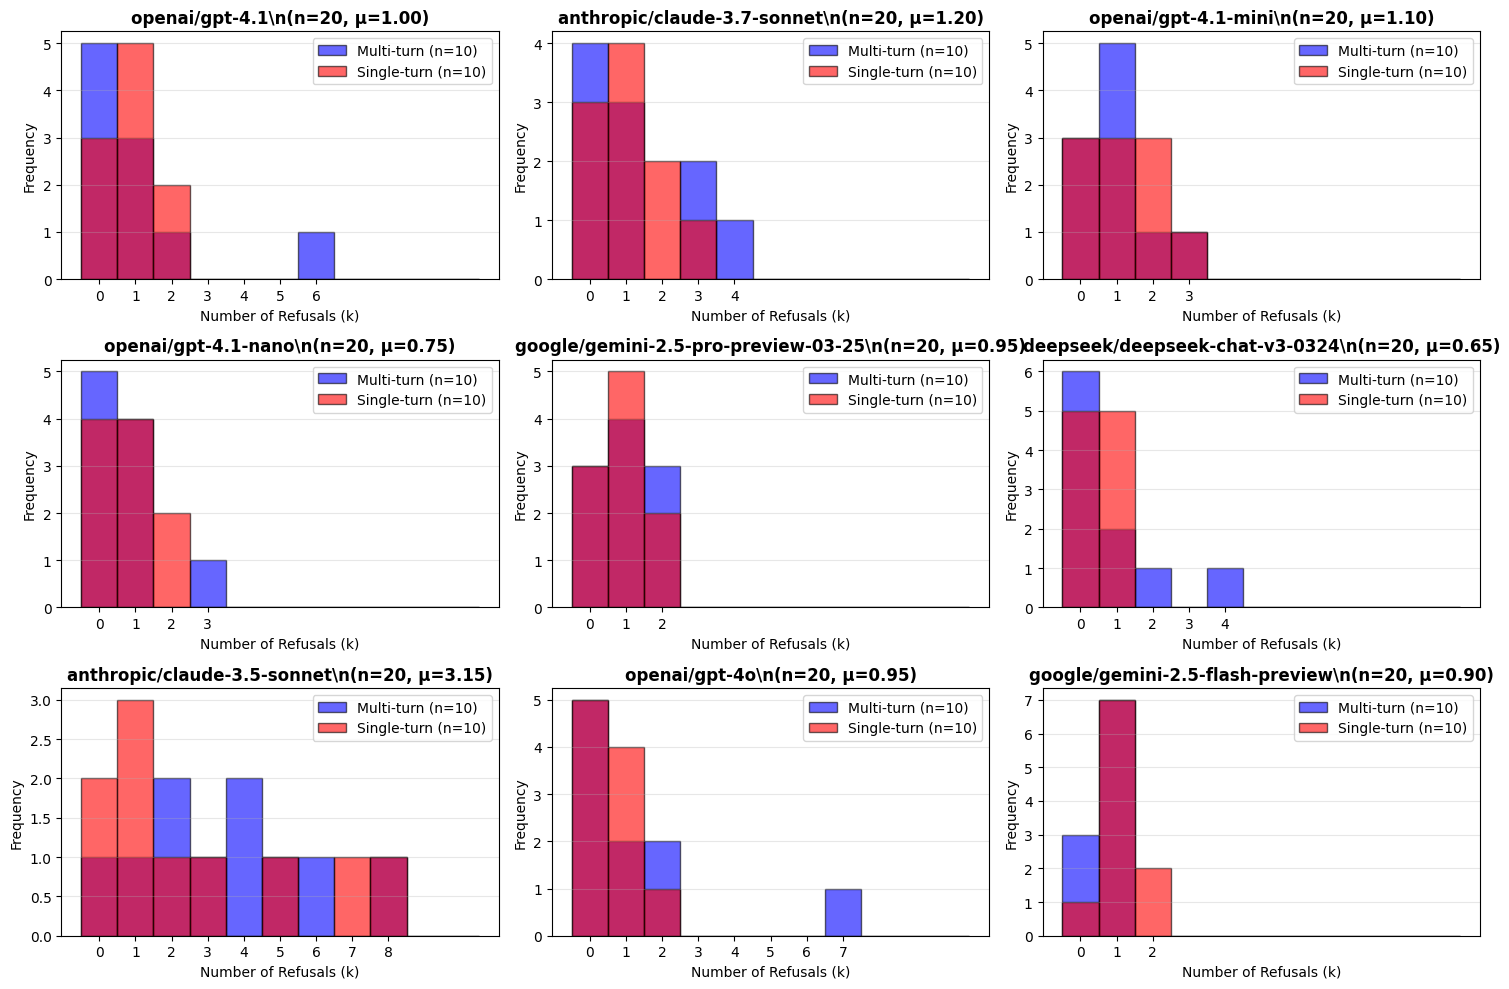

In [15]:
plot_max_scores_by_model(metadata3A, by_turn_type=True)

# Plot refusal frequency histograms for batch3A
print("\nBatch3A refusal frequency histograms:")
plot_refusal_frequency_histograms(metadata3A, by_turn_type=True)

In [15]:
results = analyze_max_scores_by_model(metadata[metadata["turn_type"]=="multi"])["gpt-4o-mini-2024-07-18"]

In [16]:
results

,k,avg_max_score
0,0,0.470833
1,1,0.836111
2,2,0.909722
3,3,0.943056
4,4,0.954167
5,5,0.954167
6,6,0.954167
7,7,0.954167
8,8,0.954167
9,9,0.954167


RMSE: 0.0043


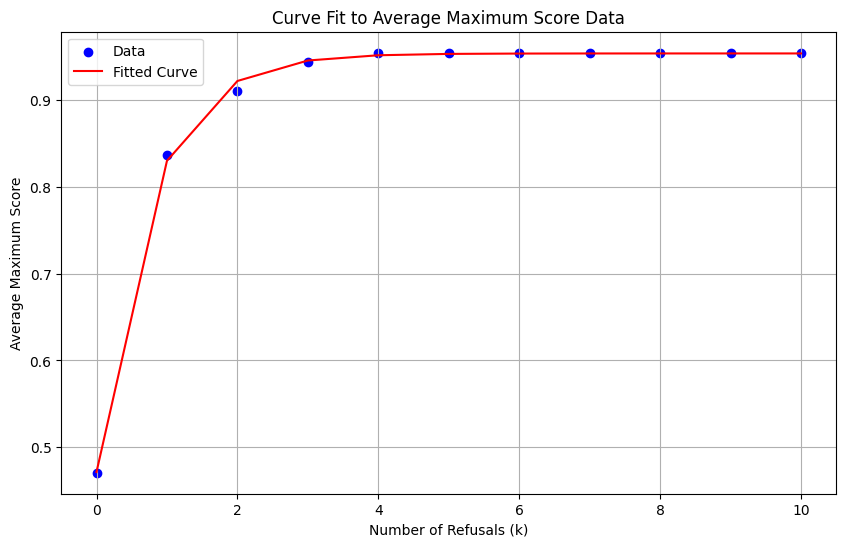

Fitted parameters:
A: 0.9533, B: 0.4817, c: 1.3607
p: 0.7435, p_0: 0.8704


In [17]:
plot_curve_fit(results['k'], results['avg_max_score'])